<a href="https://colab.research.google.com/github/AbelPhilippe/Wine_Quality_Classification/blob/main/Wine_Quality_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import sklearn.model_selection
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import kagglehub
import warnings

from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore')

In [ ]:
path = kagglehub.dataset_download("sahideseker/wine-quality-classification")

print("Path to dataset files:", path)

100%|██████████| 7.43k/7.43k [00:00<00:00, 4.38MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sahideseker/wine-quality-classification/versions/1


In [ ]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/sahideseker/wine-quality-classification/versions/1/wine_quality_classification.csv')
df

,fixed_acidity,residual_sugar,alcohol,density,quality_label
0,9.3,6.4,13.6,1.0005,high
1,11.2,2.0,14.0,0.9912,medium
2,11.6,0.9,8.2,0.9935,low
3,12.9,6.6,12.7,1.0002,low
4,13.9,13.8,10.4,0.9942,medium
...,...,...,...,...,...
995,13.0,4.3,13.1,1.0035,low
996,6.4,5.3,9.5,1.0040,low
997,4.5,9.0,13.8,0.9931,medium
998,5.3,12.2,8.1,0.9955,low


In [ ]:
df.describe()

,fixed_acidity,residual_sugar,alcohol,density
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,10.174300,7.69200,11.039900,0.997505
std,3.452693,4.20892,1.760283,0.004300
min,4.000000,0.50000,8.000000,0.990000
25%,7.100000,4.10000,9.500000,0.993900
50%,10.400000,7.55000,11.000000,0.997400
75%,13.125000,11.50000,12.600000,1.001200
max,16.000000,15.00000,14.000000,1.005000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fixed_acidity   1000 non-null   float64
 1   residual_sugar  1000 non-null   float64
 2   alcohol         1000 non-null   float64
 3   density         1000 non-null   float64
 4   quality_label   1000 non-null   object 
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [ ]:
df.isnull().sum()

,0
fixed_acidity,0
residual_sugar,0
alcohol,0
density,0
quality_label,0


In [ ]:
# prompt: remova outliers

import pandas as pd

# Assuming 'df' is your DataFrame and you want to remove outliers from all numerical columns
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered


numerical_cols = df.select_dtypes(include=np.number).columns
for col in numerical_cols:
    df = remove_outliers(df, col)

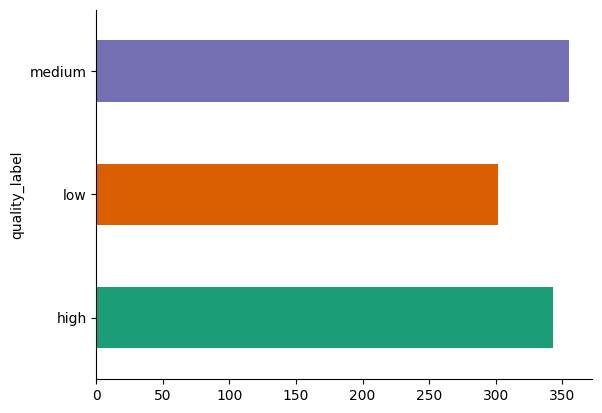

In [ ]:
df.groupby('quality_label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
le = LabelEncoder()
df['quality_label_encoded'] = le.fit_transform(df['quality_label'])
df.drop(columns=['quality_label'], inplace=True)
df

,fixed_acidity,residual_sugar,alcohol,density,quality_label_encoded
0,9.3,6.4,13.6,1.0005,0
1,11.2,2.0,14.0,0.9912,2
2,11.6,0.9,8.2,0.9935,1
3,12.9,6.6,12.7,1.0002,1
4,13.9,13.8,10.4,0.9942,2
...,...,...,...,...,...
995,13.0,4.3,13.1,1.0035,1
996,6.4,5.3,9.5,1.0040,1
997,4.5,9.0,13.8,0.9931,2
998,5.3,12.2,8.1,0.9955,1


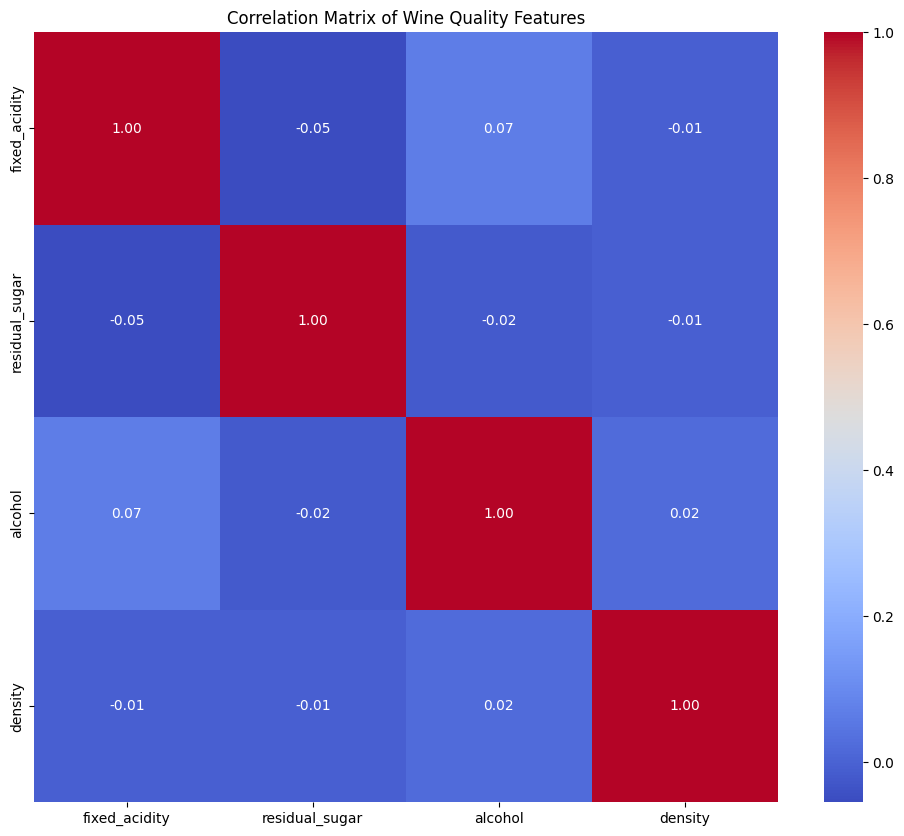

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.drop(columns=['quality_label_encoded']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Wine Quality Features')
plt.show()

# **CLASSIFICATION MODELS**

In [ ]:
models = {
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
    'Neural Network': MLPClassifier(),
    'SVM': SVC()
}

In [ ]:
X = df.drop(columns=['quality_label_encoded'])
y = df['quality_label_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
X_train, X_test

(     fixed_acidity  residual_sugar  alcohol  density
 29            11.7            13.2     12.9   1.0041
 535           15.6             6.8     11.2   1.0025
 695            9.9             7.1     10.4   0.9909
 557            6.9            11.2     12.2   1.0036
 836            8.6             5.9      8.4   1.0047
 ..             ...             ...      ...      ...
 106            9.9            14.3      8.0   0.9940
 270           15.2             6.6      8.7   0.9907
 860           14.7            12.6      9.0   1.0045
 435           10.9             0.9     13.2   0.9973
 102           11.5            14.2     11.3   0.9929
 
 [800 rows x 4 columns],
      fixed_acidity  residual_sugar  alcohol  density
 521            7.0             9.2     13.9   0.9944
 737            7.8            14.0     13.5   1.0022
 740           10.2             7.5     11.4   1.0019
 660           15.6             7.9      9.5   0.9977
 411           14.7             1.2     10.8   0.9949
 

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = X_train_scaled
X_test = X_test_scaled

In [ ]:
X_train, X_test

(array([[ 0.4275598 ,  1.31155908,  1.05675654,  1.52788434],
        [ 1.5680117 , -0.21060578,  0.08934344,  1.15742499],
        [-0.09880261, -0.1392543 , -0.36590978, -1.52840529],
        ...,
        [ 1.30483049,  1.16885613, -1.16260292,  1.62049917],
        [ 0.19362095, -1.61385151,  1.2274765 , -0.0465679 ],
        [ 0.36907509,  1.54939734,  0.1462501 , -1.06533111]]),
 array([[-9.46830945e-01,  3.60206044e-01,  1.62582307e+00,
         -7.18025468e-01],
        [-7.12892095e-01,  1.50182969e+00,  1.39819646e+00,
          1.08796386e+00],
        [-1.10755425e-02, -4.41189972e-02,  2.03156751e-01,
          1.01850273e+00],
        [ 1.56801170e+00,  5.10163067e-02, -8.78069653e-01,
          4.60469394e-02],
        [ 1.30483049e+00, -1.54250003e+00, -1.38283166e-01,
         -6.02256921e-01],
        [ 2.22863308e-01, -2.81957257e-01,  8.29129932e-01,
         -8.56947724e-01],
        [ 3.69075090e-01, -7.10066125e-01, -1.67476279e+00,
          1.38896208e+00],
    

Random Forest
              precision    recall  f1-score   support

           0       0.35      0.35      0.35        71
           1       0.31      0.24      0.27        62
           2       0.38      0.45      0.41        67

    accuracy                           0.35       200
   macro avg       0.34      0.35      0.34       200
weighted avg       0.35      0.35      0.35       200



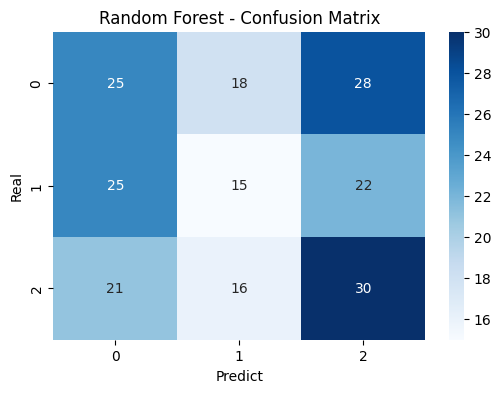

Decision Tree
              precision    recall  f1-score   support

           0       0.31      0.31      0.31        71
           1       0.21      0.21      0.21        62
           2       0.28      0.28      0.28        67

    accuracy                           0.27       200
   macro avg       0.27      0.27      0.27       200
weighted avg       0.27      0.27      0.27       200



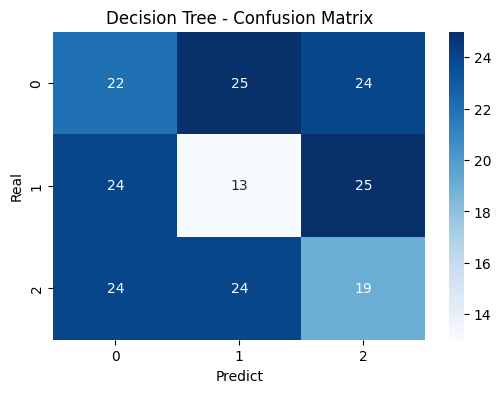

KNN
              precision    recall  f1-score   support

           0       0.38      0.51      0.43        71
           1       0.32      0.37      0.34        62
           2       0.38      0.18      0.24        67

    accuracy                           0.35       200
   macro avg       0.36      0.35      0.34       200
weighted avg       0.36      0.35      0.34       200



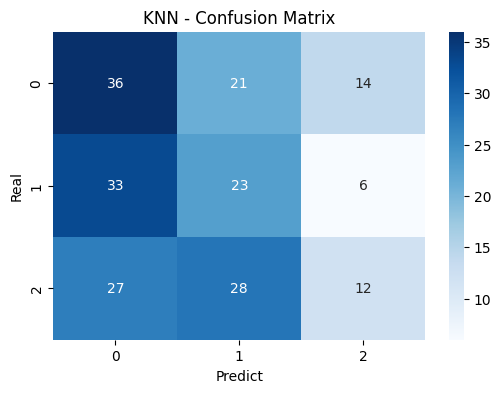

Neural Network
              precision    recall  f1-score   support

           0       0.34      0.37      0.35        71
           1       0.40      0.19      0.26        62
           2       0.39      0.55      0.46        67

    accuracy                           0.38       200
   macro avg       0.38      0.37      0.36       200
weighted avg       0.38      0.38      0.36       200



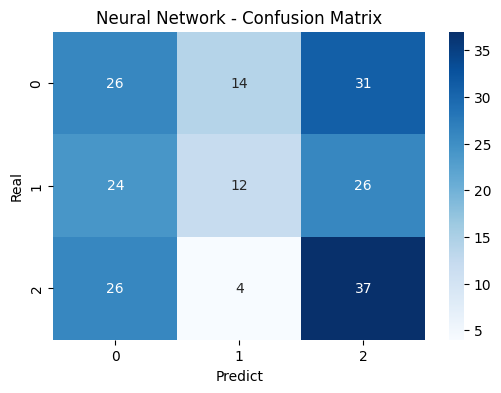

SVM
              precision    recall  f1-score   support

           0       0.41      0.44      0.42        71
           1       0.39      0.11      0.17        62
           2       0.37      0.58      0.45        67

    accuracy                           0.39       200
   macro avg       0.39      0.38      0.35       200
weighted avg       0.39      0.39      0.36       200



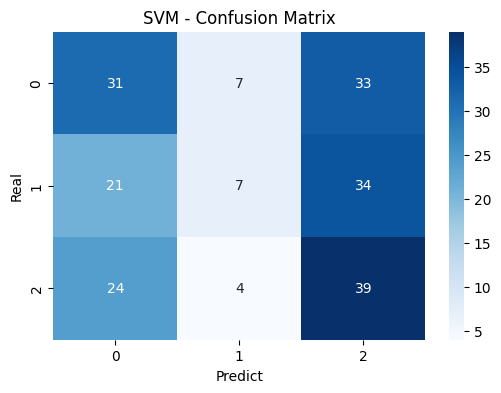

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = metrics.accuracy_score(y_test, y_pred)
    print(f'{name}')
    print(metrics.classification_report(y_test, y_pred))
    cm = metrics.confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predict')
    plt.ylabel('Real')
    plt.show()